<a href="https://colab.research.google.com/github/latikasekhri6577/Langchain-LangGraph-Course/blob/main/RAG_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

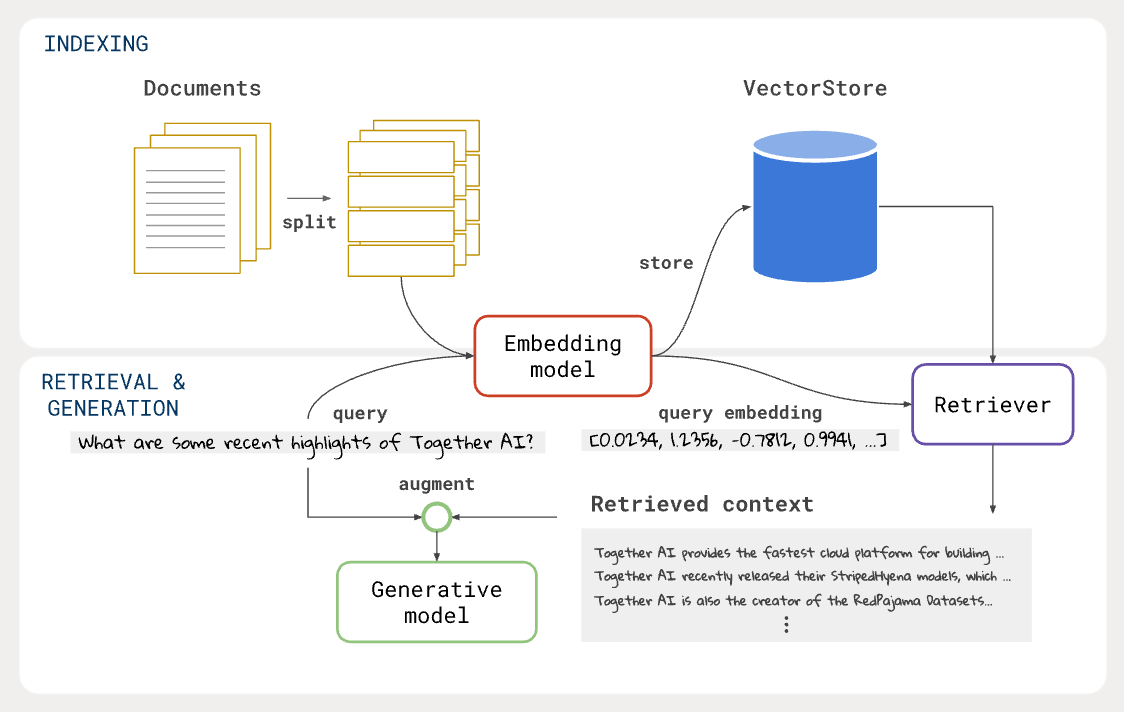

In [1]:
!pip install -q langchain langchain-community langchain-text-splitters langchain-core \
    langchain-google-genai langchain-chroma pypdf rapidocr-onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 

In [2]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Keys in DBMS.pdf to Keys in DBMS.pdf


In [6]:
# 1. Load using standard PDF text extraction (avoiding the PIL image extraction bug)
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("/content/Keys in DBMS.pdf", extract_images=False)
docs = loader.load()

# 2. Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

# Check if we successfully extracted text
if len(chunks) == 0:
    raise ValueError("No text could be extracted from the PDF. Please check if the file is corrupted or fully unreadable.")

# 3. Embed + store
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vectorstore = Chroma.from_documents(chunks, embeddings)

# 4. Retrieve
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# 5. RAG chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

prompt = ChatPromptTemplate.from_template(
    "Answer only from the context. If it isn't there, say you don't know.\n\n"
    "Context:\n{context}\n\nQuestion: {question}"
)

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt | model | StrOutputParser()
)

print(rag_chain.invoke("What is a foreign key?"))

A Foreign Key is a column that creates a relationship between two tables. The purpose of Foreign keys is to maintain data integrity and allow navigation between two different instances of an entity. It acts as a cross-reference between two tables as it references the primary key of another table.


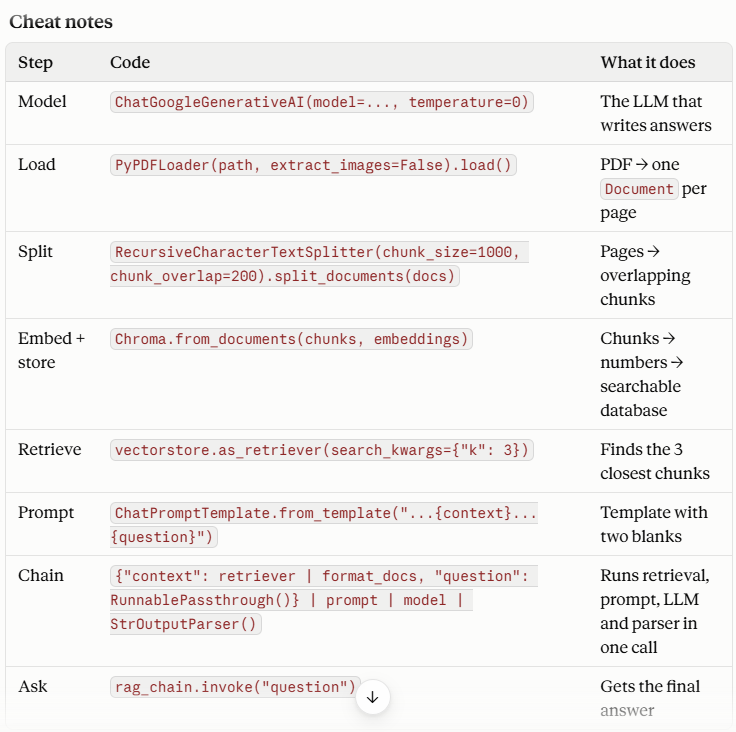